# Prédiction personnalisée client — 14 jours d'entrée → 2 jours prédits

Objectif : prédire la courbe de consommation future d'un client

A partir de 14 jours passés du client, on prédit 2 jours futurs du même client

Ce notebook compare les modèles avec :

1. une baseline récente : recopier les 2 derniers jours
2. une baseline hebdomadaire : recopier les mêmes créneaux de la semaine précédente
3. un modèle Ridge qui apprend une correction de la meilleure baseline
4. un CNN 1D résiduel léger qui apprend aussi une correction de baseline.

Le modèle reste volontairement raisonnable pour éviter un temps d'exécution trop long.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    import holidays
except ImportError:
    class _EmptyFranceHolidays:
        def __contains__(self, date):
            return False

    class holidays:
        @staticmethod
        def France(*args, **kwargs):
            print("Package 'holidays' non installé : is_holiday sera toujours égal à 0.")
            return _EmptyFranceHolidays()

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

print("Librairies chargées")
print(f"PyTorch disponible : {TORCH_AVAILABLE}")
if TORCH_AVAILABLE:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device PyTorch utilisé : {DEVICE}")
    if torch.cuda.is_available():
        print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    DEVICE = None



Librairies chargées
PyTorch disponible : True
Device PyTorch utilisé : cpu


In [ ]:

# PARAMÈTRES

from anyio import Path




BASE_DIR = Path(__file__).resolve().parent.parent

FILE_PATH = BASE_DIR / "Data" / "RES2-6-9.csv"
LABELS_PATH = BASE_DIR / "Data" / "RES2-6-9-labels.csv"   

# Séquences
INPUT_LEN = 672        # 14 jours passés × 48 demi-heures
HORIZON   = 96         # 2 jours futurs × 48 demi-heures
STRIDE    = 48         # un point de départ par jour et par client

# Le modèle utilise des informations hebdomadaires jusqu'à 14 jours dans le passé.
MIN_HISTORY_FOR_FEATURES = INPUT_LEN

# Découpage temporel
N_VAL_DAYS  = 30
N_TEST_DAYS = 30
GAP_DAYS    = HORIZON // 48   # 2 jours de gap anti-fuite

# Modèles
RIDGE_ALPHAS = [1.0, 10.0, 100.0, 300.0]
SELECTION_METRIC = "WMAPE"

# Seuil utilisé pour construire les indicateurs d'activité passée
# Un jour passé est considéré actif si son énergie journalière dépasse ce seuil.
ACTIVE_DAY_KWH = 1.0

# CNN léger pour rester sous un temps de calcul raisonnable
RUN_CNN = True
CNN_EPOCHS = 8
CNN_BATCH_SIZE = 512
CNN_LR = 1e-3
CNN_WEIGHT_DECAY = 1e-4
MAX_TRAIN_SAMPLES_CNN = 60000
MAX_VAL_SAMPLES_CNN = 20000
RANDOM_STATE = 42

# Pour accélérer les essais, mettre par exemple 50.
# Pour le rendu final, laisser None.
MAX_CLIENTS_PER_SEGMENT = None

np.random.seed(RANDOM_STATE)
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

print(f"Entrée : {INPUT_LEN} demi-heures = {INPUT_LEN // 48} jours")
print(f"Sortie : {HORIZON} demi-heures = {HORIZON // 48} jours")
print(f"Stride : {STRIDE} demi-heures = {STRIDE // 48} jour")
print(f"Validation : {N_VAL_DAYS} jours | Test : {N_TEST_DAYS} jours | Gap : {GAP_DAYS} jours")



Entrée : 672 demi-heures = 14 jours
Sortie : 96 demi-heures = 2 jours
Stride : 48 demi-heures = 1 jour
Validation : 30 jours | Test : 30 jours | Gap : 2 jours


## 1. Chargement des données
Le projet utilise deux fichiers principaux :

- RES2-6-9.csv

- RES2-6-9-labels.csv

Le fichier de consommation contient les courbes de charge au pas de 30 minutes.
Après chargement, les colonnes utilisées sont :

- pdl_id : identifiant du client / point de livraison

- horodate : date et heure de la mesure

- puissance_w : puissance appelée en watts

Le fichier de labels contient les classes de clients :
- pdl_id
- label_rs_rp
- cluster_ref

La convention utilisée est :

- 0 = RS : résidence secondaire

- 1 = RP : résidence principale

In [ ]:
#  Étiquettes RS / RP 
ref = pd.read_csv(LABELS_PATH)
ref.columns = ["pdl_id", "label_rs_rp", "cluster_ref"]

# Convention du fichier labels : 0 = RS, 1 = RP
ref["segment"] = np.where(ref["label_rs_rp"] == 0, "RS", "RP")

print("Répartition des clients dans les labels :")
print(ref["segment"].value_counts())

#Données brutes 
raw = pd.read_csv(FILE_PATH)
raw.columns = ["pdl_id", "horodate", "puissance_w"]

raw["horodate"] = pd.to_datetime(raw["horodate"], utc=True, errors="coerce")
raw["puissance_w"] = pd.to_numeric(raw["puissance_w"], errors="coerce")
raw = raw.dropna(subset=["pdl_id", "horodate", "puissance_w"])

# Ajout du segment RS/RP ; on ne garde que les PDL labellisés.
raw = raw.merge(ref[["pdl_id", "label_rs_rp", "segment"]], on="pdl_id", how="inner")

# Conversion W au pas 30 min → kWh sur 30 min
raw["kwh"] = raw["puissance_w"] * 0.5 / 1000

# Tri par client et par date
raw = raw.sort_values(["pdl_id", "horodate"]).reset_index(drop=True)

# Option pour réduire le nombre de clients pendant les essais
if MAX_CLIENTS_PER_SEGMENT is not None:
    keep_pdls = []
    for seg in ["RS", "RP"]:
        pdls_seg = raw.loc[raw["segment"] == seg, "pdl_id"].drop_duplicates()
        keep_pdls.extend(pdls_seg.head(MAX_CLIENTS_PER_SEGMENT).tolist())
    raw = raw[raw["pdl_id"].isin(keep_pdls)].copy()

print(f"Lignes : {len(raw):,}")
print(f"Période : {raw['horodate'].min()} → {raw['horodate'].max()}")
print(f"Clients : {raw['pdl_id'].nunique()}")
print("Répartition des lignes :")
print(raw["segment"].value_counts())

display(raw.head())


Répartition des clients dans les labels :
segment
RS    428
RP     72
Name: count, dtype: int64
Lignes : 8,736,000
Période : 2023-10-31 23:00:00+00:00 → 2024-10-29 22:30:00+00:00
Clients : 500
Répartition des lignes :
segment
RS    7478016
RP    1257984
Name: count, dtype: int64


,pdl_id,horodate,puissance_w,label_rs_rp,segment,kwh
0,1704875583,2023-10-31 23:00:00+00:00,308.8,0,RS,0.15440
1,1704875583,2023-10-31 23:30:00+00:00,330.4,0,RS,0.16520
2,1704875583,2023-11-01 00:00:00+00:00,299.0,0,RS,0.14950
3,1704875583,2023-11-01 00:30:00+00:00,245.7,0,RS,0.12285
4,1704875583,2023-11-01 01:00:00+00:00,258.9,0,RS,0.12945


## 2. Fonctions de métriques et features

### 2.1 Métriques utilisées

On calcule les métriques suivantes :
- MAE
- RMSE
- WMAPE
- MAPE filtré
- sMAPE

### 2.2 Features

En ce qui concerne les features, pour chaque exemple, le modèle utilise deux types d’informations :

X_tab = [X_seq, X_extra]

avec :

- X_seq : courbe brute des 14 jours passés

- X_extra : variables explicatives supplémentaires

X_extra contient des variables calendaires, des lags individuels, des statistiques sur l'historique et des variables d'activité passé.

Pour plus d'informations, regarder le README

In [4]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 1e-8
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom <= 1e-8:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom * 100


def mape_raw(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) <= 1e-8, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100


def filtered_mape(y_true, y_pred, threshold=0.10):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    out = {
        prefix + "MAE": mean_absolute_error(y_true, y_pred),
        prefix + "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        prefix + "WMAPE": wmape(y_true, y_pred),
        prefix + "sMAPE": smape(y_true, y_pred),
        prefix + "MAPE_brut": mape_raw(y_true, y_pred),
        prefix + "MAPE_filtre_010": filtered_mape(y_true, y_pred, threshold=0.10),
    }
    return out


def print_metrics(title, metrics):
    print("=" * 70)
    print(title)
    print("=" * 70)
    for k, v in metrics.items():
        if isinstance(v, (float, np.floating)):
            if "MAPE" in k or "WMAPE" in k or "sMAPE" in k:
                print(f"{k:18s}: {v:8.2f} %")
            else:
                print(f"{k:18s}: {v:8.4f}")
        else:
            print(f"{k:18s}: {v}")


In [5]:
# Jours fériés France, avec fallback si le package holidays n'est pas installé
annees = sorted(raw["horodate"].dt.year.unique())
fr_holidays = holidays.France(years=annees)


def is_school_holiday_proxy(dt):
    """Proxy simple : mois de vacances fréquentes en France."""
    m = dt.month
    return int(m in [7, 8, 12])


def season_from_month(m):
    if m in [12, 1, 2]:
        return 0  # hiver
    if m in [3, 4, 5]:
        return 1  # printemps
    if m in [6, 7, 8]:
        return 2  # été
    return 3      # automne


def longest_run_bool(values):
    best = 0
    cur = 0
    for v in values:
        if v:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best


def build_extra_features(past_seq, anchor_time, segment):
    """Features disponibles au moment de la prédiction.
    past_seq : 14 jours passés, longueur INPUT_LEN.
    anchor_time : dernier horodatage observé.
    segment : 'RS' ou 'RP'.
    """
    past_seq = np.asarray(past_seq, dtype=np.float32)
    forecast_start = anchor_time + pd.Timedelta(minutes=30)
    dow = forecast_start.weekday()
    month = forecast_start.month
    season = season_from_month(month)

    last_1d = past_seq[-48:]
    last_2d = past_seq[-96:]
    last_7d = past_seq[-336:]
    last_14d = past_seq[-672:]

    # Activité passée au pas 30 min et au niveau jour
    active_30 = past_seq > 0.02
    daily_energy_14 = last_14d.reshape(-1, 48).sum(axis=1)
    active_days_14 = daily_energy_14 > ACTIVE_DAY_KWH
    daily_energy_7 = last_7d.reshape(-1, 48).sum(axis=1)
    active_days_7 = daily_energy_7 > ACTIVE_DAY_KWH

    # Week-end / semaine sur les 14 jours passés.
    # On reconstruit les jours passés à partir de forecast_start.
    past_day_dates = [forecast_start.normalize() - pd.Timedelta(days=d) for d in range(14, 0, -1)]
    is_weekend_past = np.array([d.weekday() >= 5 for d in past_day_dates])

    weekday_energy = daily_energy_14[~is_weekend_past].sum() if (~is_weekend_past).any() else 0.0
    weekend_energy = daily_energy_14[is_weekend_past].sum() if is_weekend_past.any() else 0.0

    eps = 1e-6
    feats = []

    # Calendrier du début de prévision
    feats.extend([
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        float(dow >= 5),
        np.sin(2 * np.pi * month / 12),
        np.cos(2 * np.pi * month / 12),
        float(forecast_start.date() in fr_holidays),
        float(is_school_holiday_proxy(forecast_start)),
    ])
    feats.extend([float(season == s) for s in range(4)])
    feats.extend([float(segment == "RS"), float(segment == "RP")])

    # Lags individuels inspirés du hackathon
    feats.extend([
        past_seq[-1],
        past_seq[-48],
        past_seq[-96],
        past_seq[-336],
        past_seq[-672],
    ])

    # Statistiques mobiles sur 1, 2, 7 et 14 jours
    for arr in [last_1d, last_2d, last_7d, last_14d]:
        feats.extend([
            arr.mean(),
            arr.std(),
            arr.min(),
            arr.max(),
            arr.sum(),
        ])

    # Activité passée
    feats.extend([
        active_30[-48:].mean(),
        active_30[-96:].mean(),
        active_30[-336:].mean(),
        active_30[-672:].mean(),
        active_days_7.mean(),
        active_days_14.mean(),
        active_days_7.sum(),
        active_days_14.sum(),
        longest_run_bool(active_days_14),
        daily_energy_7.mean(),
        daily_energy_7.std(),
        daily_energy_14.mean(),
        daily_energy_14.std(),
        weekend_energy,
        weekday_energy,
        weekend_energy / (weekday_energy + eps),
    ])

    # Comparaisons de niveaux récents
    feats.extend([
        last_7d.mean() / (last_14d.mean() + eps),
        last_2d.mean() / (last_7d.mean() + eps),
        last_1d.mean() / (last_7d.mean() + eps),
        last_7d.mean() - last_14d.mean(),
        last_2d.mean() - last_7d.mean(),
        last_1d.mean() - last_7d.mean(),
    ])

    return np.asarray(feats, dtype=np.float32)


EXTRA_FEATURE_NAMES = [
    "dow_sin", "dow_cos", "is_weekend_start", "month_sin", "month_cos",
    "is_holiday_start", "is_school_holiday_proxy",
    "season_winter", "season_spring", "season_summer", "season_autumn",
    "is_RS", "is_RP",
    "lag_1", "lag_48", "lag_96", "lag_336", "lag_672",
]
for w_name in ["1d", "2d", "7d", "14d"]:
    EXTRA_FEATURE_NAMES += [f"mean_{w_name}", f"std_{w_name}", f"min_{w_name}", f"max_{w_name}", f"sum_{w_name}"]
EXTRA_FEATURE_NAMES += [
    "active_rate_1d", "active_rate_2d", "active_rate_7d", "active_rate_14d",
    "active_days_rate_7d", "active_days_rate_14d", "active_days_count_7d", "active_days_count_14d",
    "longest_active_run_14d", "daily_energy_7d_mean", "daily_energy_7d_std",
    "daily_energy_14d_mean", "daily_energy_14d_std", "weekend_energy_14d", "weekday_energy_14d",
    "weekend_over_weekday_energy", "ratio_mean_7d_14d", "ratio_mean_2d_7d", "ratio_mean_1d_7d",
    "diff_mean_7d_14d", "diff_mean_2d_7d", "diff_mean_1d_7d",
]
print(f"Nombre de features extra : {len(EXTRA_FEATURE_NAMES)}")


Nombre de features extra : 60


## 3. Construction des fenêtres client par client

Chaque exemple est construit ainsi :

```text
X_seq    = 14 jours passés du client, 672 valeurs
X_extra  = tous les autres features
Y        = 2 jours futurs du même client, 96 valeurs
```

Pour chaque client, le programme construit des fenêtres temporelles glissantes.

Le paramètre utilisé est STRIDE = 48

In [6]:
def build_windows_for_client(g):
    g = g.sort_values("horodate")
    values = g["kwh"].to_numpy(dtype=np.float32)
    times = g["horodate"].to_numpy()
    pdl = g["pdl_id"].iloc[0]
    segment = g["segment"].iloc[0]

    n = len(g)
    rows = []
    max_start = n - INPUT_LEN - HORIZON
    if max_start < 0:
        return rows

    for start in range(0, max_start + 1, STRIDE):
        input_end = start + INPUT_LEN
        target_end = input_end + HORIZON

        past_seq = values[start:input_end]
        future_seq = values[input_end:target_end]
        anchor_time = pd.Timestamp(times[input_end - 1])
        forecast_start = anchor_time + pd.Timedelta(minutes=30)

        # Baseline récente : on recopie les 2 derniers jours observés
        baseline_recent = past_seq[-HORIZON:]

        # Baseline hebdomadaire : mêmes créneaux de la semaine précédente
        weekly_start = INPUT_LEN - 336
        weekly_end = weekly_start + HORIZON
        baseline_weekly = past_seq[weekly_start:weekly_end]

        extra = build_extra_features(past_seq, anchor_time, segment)

        rows.append({
            "pdl_id": pdl,
            "segment": segment,
            "anchor_time": anchor_time,
            "forecast_start": forecast_start,
            "X_seq": past_seq,
            "X_extra": extra,
            "Y": future_seq,
            "baseline_recent": baseline_recent,
            "baseline_weekly": baseline_weekly,
        })

    return rows


all_rows = []
for i, (_, g) in enumerate(raw.groupby("pdl_id"), start=1):
    all_rows.extend(build_windows_for_client(g))
    if i % 100 == 0:
        print(f"Clients traités : {i}")

windows = pd.DataFrame(all_rows)
print(f"Nombre total de fenêtres : {len(windows):,}")
print("Fenêtres par segment :")
print(windows["segment"].value_counts())
print(f"Période des départs de prévision : {windows['forecast_start'].min()} → {windows['forecast_start'].max()}")

display(windows.head())



Clients traités : 100
Clients traités : 200
Clients traités : 300
Clients traités : 400
Clients traités : 500
Nombre total de fenêtres : 174,500
Fenêtres par segment :
segment
RS    149372
RP     25128
Name: count, dtype: int64
Période des départs de prévision : 2023-11-14 23:00:00+00:00 → 2024-10-27 23:00:00+00:00


,pdl_id,segment,anchor_time,forecast_start,X_seq,X_extra,Y,baseline_recent,baseline_weekly
0,1704875583,RS,2023-11-14 22:30:00+00:00,2023-11-14 23:00:00+00:00,"[0.1544, 0.1652, 0.1495, 0.12285, 0.12945, 0.1...","[0.7818315, 0.6234898, 0.0, -0.5, 0.8660254, 0...","[0.31785, 0.29115, 0.214, 0.1949, 0.29905, 0.6...","[0.23965, 0.2425, 0.17455, 0.21485, 0.1685, 0....","[0.234, 0.179, 0.2162, 0.22185, 0.2208, 0.231,..."
1,1704875583,RS,2023-11-15 22:30:00+00:00,2023-11-15 23:00:00+00:00,"[0.1543, 0.1788, 0.17145, 0.14245, 0.15415, 0....","[0.9749279, -0.22252093, 0.0, -0.5, 0.8660254,...","[0.22965, 0.07765, 0.0556, 0.2082, 0.1273, 0.2...","[0.18825, 0.16735, 0.08705, 0.05375, 0.1145, 0...","[0.21545, 0.1786, 0.1614, 0.154, 0.1804, 0.192..."
2,1704875583,RS,2023-11-16 22:30:00+00:00,2023-11-16 23:00:00+00:00,"[0.18945, 0.2, 0.25435, 0.1895, 0.1799, 0.6890...","[0.43388373, -0.90096885, 0.0, -0.5, 0.8660254...","[0.29805, 0.2242, 0.16245, 0.20535, 0.1769, 0....","[0.31785, 0.29115, 0.214, 0.1949, 0.29905, 0.6...","[0.20965, 0.20825, 0.14525, 0.1938, 0.1855, 0...."
3,1704875583,RS,2023-11-17 22:30:00+00:00,2023-11-17 23:00:00+00:00,"[0.19875, 0.16465, 0.193, 0.15725, 0.20135, 0....","[-0.43388373, -0.90096885, 0.0, -0.5, 0.866025...","[0.15115, 0.25135, 0.2772, 0.2716, 0.23035, 0....","[0.22965, 0.07765, 0.0556, 0.2082, 0.1273, 0.2...","[0.19135, 0.23525, 0.30305, 0.2082, 0.2744, 0...."
4,1704875583,RS,2023-11-18 22:30:00+00:00,2023-11-18 23:00:00+00:00,"[0.1694, 0.14415, 0.1348, 0.1251, 0.1393, 0.14...","[-0.9749279, -0.22252093, 1.0, -0.5, 0.8660254...","[0.28125, 0.254, 0.29395, 0.29995, 0.3331, 0.4...","[0.29805, 0.2242, 0.16245, 0.20535, 0.1769, 0....","[0.22835, 0.11285, 0.0976, 0.23035, 0.15805, 0..."


In [7]:
# Conversion en matrices numpy
X_seq = np.stack(windows["X_seq"].values).astype(np.float32)
X_extra = np.stack(windows["X_extra"].values).astype(np.float32)
Y = np.stack(windows["Y"].values).astype(np.float32)
B_recent = np.stack(windows["baseline_recent"].values).astype(np.float32)
B_weekly = np.stack(windows["baseline_weekly"].values).astype(np.float32)
segments = windows["segment"].values
forecast_starts = pd.to_datetime(windows["forecast_start"])

print(f"X_seq    : {X_seq.shape}")
print(f"X_extra  : {X_extra.shape}")
print(f"Y        : {Y.shape}")
print(f"B_recent : {B_recent.shape}")
print(f"B_weekly : {B_weekly.shape}")



X_seq    : (174500, 672)
X_extra  : (174500, 60)
Y        : (174500, 96)
B_recent : (174500, 96)
B_weekly : (174500, 96)


## 4. Séparation temporelle train / validation / test

Le découpage se fait par date de début de prévision (`forecast_start`).  
Le test correspond aux 30 derniers jours de départ de prédiction. La validation correspond aux 30 jours précédant le test. Le train contient toutes les fenêtres disponibles avant la validation.  
Un gap de 2 jours est conservé pour éviter le chevauchement entre les cibles de train/validation/test.

In [8]:
max_time = forecast_starts.max()
test_start = max_time - pd.Timedelta(days=N_TEST_DAYS)
val_end = test_start - pd.Timedelta(days=GAP_DAYS)
val_start = val_end - pd.Timedelta(days=N_VAL_DAYS)
train_end = val_start - pd.Timedelta(days=GAP_DAYS)

idx_train = np.where(forecast_starts < train_end)[0]
idx_val = np.where((forecast_starts >= val_start) & (forecast_starts < val_end))[0]
idx_test = np.where(forecast_starts >= test_start)[0]

print("=" * 70)
print("SÉPARATION TEMPORELLE")
print("=" * 70)
print(f"Train : {len(idx_train):,} exemples | avant {train_end}")
print(f"Val   : {len(idx_val):,} exemples | {val_start} → {val_end}")
print(f"Test  : {len(idx_test):,} exemples | à partir de {test_start}")
print(f"Gap train-val : {GAP_DAYS} jours")
print(f"Gap val-test  : {GAP_DAYS} jours")

# Vérification anti-fuite approximative sur les débuts de prévision
if len(idx_train) > 0 and len(idx_val) > 0:
    last_train_target = forecast_starts.iloc[idx_train].max() + pd.Timedelta(minutes=30 * (HORIZON - 1))
    first_val_start = forecast_starts.iloc[idx_val].min()
    print("\nVérification train → validation :")
    print(f"Dernière cible train : {last_train_target}")
    print(f"Premier départ val   : {first_val_start}")
    print("OK" if last_train_target < first_val_start else "Attention : chevauchement possible")

if len(idx_val) > 0 and len(idx_test) > 0:
    last_val_target = forecast_starts.iloc[idx_val].max() + pd.Timedelta(minutes=30 * (HORIZON - 1))
    first_test_start = forecast_starts.iloc[idx_test].min()
    print("\nVérification validation → test :")
    print(f"Dernière cible val : {last_val_target}")
    print(f"Premier départ test : {first_test_start}")
    print("OK" if last_val_target < first_test_start else "Attention : chevauchement possible")


SÉPARATION TEMPORELLE
Train : 142,000 exemples | avant 2024-08-24 23:00:00+00:00
Val   : 15,000 exemples | 2024-08-26 23:00:00+00:00 → 2024-09-25 23:00:00+00:00
Test  : 15,500 exemples | à partir de 2024-09-27 23:00:00+00:00
Gap train-val : 2 jours
Gap val-test  : 2 jours

Vérification train → validation :
Dernière cible train : 2024-08-25 22:30:00+00:00
Premier départ val   : 2024-08-26 23:00:00+00:00
OK

Vérification validation → test :
Dernière cible val : 2024-09-26 22:30:00+00:00
Premier départ test : 2024-09-27 23:00:00+00:00
OK


## 5. Baselines

On compare d'abord deux méthodes simples, client par client :

- `recent` : recopier les 2 derniers jours ;
- `weekly` : recopier les mêmes créneaux de la semaine précédente.

La meilleure baseline en validation sera utilisée comme base résiduelle pour Ridge et CNN.

In [9]:
def evaluate_prediction_by_segment(y_true, y_pred, idx, name):
    """Évalue une prédiction par segment.

    Cette fonction accepte deux formats de y_pred :
    - prédiction complète de taille len(Y), par exemple B_recent ou B_weekly ;
    - prédiction locale de taille len(idx), par exemple les prédictions validation/test
      calculées uniquement sur idx_val ou idx_test.

    Cela évite les erreurs du type :
    IndexError: index ... is out of bounds for axis 0 with size len(idx)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    idx = np.asarray(idx, dtype=int)

    rows = []
    local_positions = np.arange(len(idx))

    for seg in ["RS", "RP", "ALL"]:
        if seg == "ALL":
            global_idx = idx
            local_idx = local_positions
        else:
            seg_mask = segments[idx] == seg
            global_idx = idx[seg_mask]
            local_idx = local_positions[seg_mask]

        if len(global_idx) == 0:
            continue

        # y_true est normalement complet, mais on garde une gestion robuste.
        if y_true.shape[0] == len(idx):
            yt = y_true[local_idx]
        else:
            yt = y_true[global_idx]

        # Cas 1 : y_pred contient toutes les lignes du dataset.
        if y_pred.shape[0] == len(segments):
            yp = y_pred[global_idx]
        # Cas 2 : y_pred contient uniquement les prédictions pour idx.
        elif y_pred.shape[0] == len(idx):
            yp = y_pred[local_idx]
        else:
            raise ValueError(
                "Taille incompatible pour y_pred : "
                f"{y_pred.shape[0]} lignes, alors que len(idx)={len(idx)} "
                f"et len(segments)={len(segments)}."
            )

        m = regression_metrics(yt, yp)
        m["segment"] = seg
        m["modele"] = name
        m["n_examples"] = len(global_idx)
        rows.append(m)

    return pd.DataFrame(rows)


baseline_val_recent = evaluate_prediction_by_segment(Y, B_recent, idx_val, "baseline_recent")
baseline_val_weekly = evaluate_prediction_by_segment(Y, B_weekly, idx_val, "baseline_weekly")
baseline_val = pd.concat([baseline_val_recent, baseline_val_weekly], ignore_index=True)

print("Résultats validation — baselines")
display(baseline_val[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]])

# Choix de la baseline par segment selon WMAPE validation
baseline_choice = {}
for seg in ["RS", "RP", "ALL"]:
    df_seg = baseline_val[baseline_val["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg) > 0:
        baseline_choice[seg] = df_seg.iloc[0]["modele"]

print("Choix de baseline selon la validation :")
for seg, choice in baseline_choice.items():
    print(f"  {seg} : {choice}")

# Pour entraîner un modèle global simple, on choisit la meilleure baseline ALL.
BASELINE_MODEL = baseline_choice.get("ALL", "baseline_weekly")
print(f"\nBaseline utilisée pour les modèles résiduels : {BASELINE_MODEL}")

B_base = B_recent if BASELINE_MODEL == "baseline_recent" else B_weekly



Résultats validation — baselines


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,baseline_recent,RS,12840,0.141065,0.286241,65.963684,63.498856,61.154659
1,baseline_recent,RP,2160,0.120461,0.264845,59.116234,60.874210,59.578293
2,baseline_recent,ALL,15000,0.138098,0.283259,65.017715,63.158333,60.943501
3,baseline_weekly,RS,12840,0.159819,0.312514,74.733261,71.853355,68.170792
4,baseline_weekly,RP,2160,0.137292,0.289753,67.376205,68.792656,68.603294
5,baseline_weekly,ALL,15000,0.156575,0.309340,73.716888,71.456253,68.229637


Choix de baseline selon la validation :
  RS : baseline_recent
  RP : baseline_recent
  ALL : baseline_recent

Baseline utilisée pour les modèles résiduels : baseline_recent


## 6. Ridge résiduel
Le modèle Ridge ne prédit pas directement la courbe future.  
Il apprend une correction à appliquer à la baseline récente.  

On définit :  
résidu = vraie courbe future − baseline  

Puis le modèle apprend à prédire ce résidu. La prédiction finale est donc :  
bY = Ybaseline + bR  
avec bR le résidu prédit par le modèle Ridge.

In [10]:
# Matrice de features tabulaires : séquence brute + features extra
X_tab = np.hstack([X_seq, X_extra]).astype(np.float32)
Y_residual = (Y - B_base).astype(np.float32)

print(f"X_tab      : {X_tab.shape}")
print(f"Y_residual : {Y_residual.shape}")


X_tab      : (174500, 732)
Y_residual : (174500, 96)


In [20]:
# Sélection de alpha Ridge sur validation
ridge_results = []
ridge_models = {}

for alpha in RIDGE_ALPHAS:
    print(f"Entraînement Ridge alpha={alpha}")
    model = make_pipeline(
        StandardScaler(with_mean=True),
        Ridge(alpha=alpha)
    )
    model.fit(X_tab[idx_train], Y_residual[idx_train])
    ridge_models[alpha] = model

    pred_res_val = model.predict(X_tab[idx_val]).astype(np.float32)
    pred_val = np.clip(B_base[idx_val] + pred_res_val, 0, None)
    metrics_val = regression_metrics(Y[idx_val], pred_val)
    metrics_val["alpha"] = alpha
    ridge_results.append(metrics_val)

ridge_results = pd.DataFrame(ridge_results).sort_values(SELECTION_METRIC).reset_index(drop=True)
print("Résultats validation — Ridge résiduel")
display(ridge_results)

best_alpha = float(ridge_results.iloc[0]["alpha"])
ridge_model = ridge_models[best_alpha]
print(f"Meilleur alpha Ridge selon {SELECTION_METRIC} : {best_alpha}")


Entraînement Ridge alpha=1.0
Entraînement Ridge alpha=10.0
Entraînement Ridge alpha=100.0
Entraînement Ridge alpha=300.0
Résultats validation — Ridge résiduel


,MAE,RMSE,WMAPE,sMAPE,MAPE_brut,MAPE_filtre_010,alpha
0,0.129603,0.217788,61.017918,69.066231,1088.365601,53.337906,1.0
1,0.129603,0.217788,61.018188,69.065994,1088.414307,53.337936,10.0
2,0.129609,0.217787,61.020897,69.065254,1088.893188,53.338326,100.0
3,0.129624,0.217789,61.028099,69.064728,1089.951172,53.340424,300.0


Meilleur alpha Ridge selon WMAPE : 1.0


In [12]:
# Évaluation Ridge sur validation
pred_res_val = ridge_model.predict(X_tab[idx_val]).astype(np.float32)
pred_ridge_val = np.clip(B_base[idx_val] + pred_res_val, 0, None)

ridge_val_table = evaluate_prediction_by_segment(
    Y,
    pred_ridge_val,
    idx_val,
    "ridge_residual"
)

print("Résultats validation — Ridge résiduel")
display(
    ridge_val_table[
        ["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]
    ]
)




Résultats validation — Ridge résiduel


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,ridge_residual,RS,12840,0.132331,0.220082,61.879425,53.675426,68.144920
1,ridge_residual,RP,2160,0.113384,0.203622,55.643326,51.073914,74.688766
2,ridge_residual,ALL,15000,0.129603,0.217788,61.017918,53.337906,69.066231


## 7. CNN 1D résiduel léger

Le CNN reçoit :

- la séquence des 14 jours passés ;
- les features extra individuelles.

Il apprend une correction de baseline comme Ridge :

```text
Y_pred = baseline + correction_CNN
```

Le modèle est volontairement léger, avec sous-échantillonnage du train pour limiter le temps de calcul.

In [13]:
if not TORCH_AVAILABLE:
    print("PyTorch n'est pas disponible : la partie CNN est ignorée.")
    RUN_CNN = False

class SequenceDataset(Dataset):
    def __init__(self, idx, x_seq, x_extra, y_res):
        self.idx = np.asarray(idx)
        self.x_seq = x_seq
        self.x_extra = x_extra
        self.y_res = y_res

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        return (
            torch.from_numpy(self.x_seq[j]),
            torch.from_numpy(self.x_extra[j]),
            torch.from_numpy(self.y_res[j]),
        )

class ResidualCNN1D(nn.Module):
    def __init__(self, n_extra, output_len):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32),
            nn.Flatten(),
        )
        cnn_dim = 64 * 32
        self.head = nn.Sequential(
            nn.Linear(cnn_dim + n_extra, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, output_len),
        )

    def forward(self, x_seq, x_extra):
        x = x_seq.unsqueeze(1)
        h = self.cnn(x)
        z = torch.cat([h, x_extra], dim=1)
        return self.head(z)

print("Classes CNN prêtes")


Classes CNN prêtes


In [14]:
def sample_indices(idx, max_samples, seed=RANDOM_STATE):
    idx = np.asarray(idx)
    if max_samples is None or len(idx) <= max_samples:
        return idx
    rng = np.random.default_rng(seed)
    return rng.choice(idx, size=max_samples, replace=False)

cnn_model = None
cnn_history = []

if RUN_CNN:
    idx_train_cnn = sample_indices(idx_train, MAX_TRAIN_SAMPLES_CNN, seed=RANDOM_STATE)
    idx_val_cnn = sample_indices(idx_val, MAX_VAL_SAMPLES_CNN, seed=RANDOM_STATE + 1)

    # Standardisation des features extra pour le CNN uniquement.
    extra_mean = X_extra[idx_train_cnn].mean(axis=0, keepdims=True)
    extra_std = X_extra[idx_train_cnn].std(axis=0, keepdims=True) + 1e-6
    X_extra_cnn = ((X_extra - extra_mean) / extra_std).astype(np.float32)

    # Standardisation légère de la séquence par un facteur global pour stabiliser l'entraînement.
    seq_scale = np.percentile(X_seq[idx_train_cnn], 95)
    if not np.isfinite(seq_scale) or seq_scale <= 1e-6:
        seq_scale = 1.0
    X_seq_cnn = (X_seq / seq_scale).astype(np.float32)
    Y_residual_cnn = (Y_residual / seq_scale).astype(np.float32)

    train_loader = DataLoader(
        SequenceDataset(idx_train_cnn, X_seq_cnn, X_extra_cnn, Y_residual_cnn),
        batch_size=CNN_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        SequenceDataset(idx_val_cnn, X_seq_cnn, X_extra_cnn, Y_residual_cnn),
        batch_size=CNN_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    cnn_model = ResidualCNN1D(n_extra=X_extra.shape[1], output_len=HORIZON).to(DEVICE)
    optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)
    loss_fn = nn.SmoothL1Loss()

    best_val_loss = np.inf
    best_state = None
    patience = 2
    patience_count = 0

    print(f"Train CNN : {len(idx_train_cnn):,} exemples | Val CNN : {len(idx_val_cnn):,} exemples")
    for epoch in range(1, CNN_EPOCHS + 1):
        cnn_model.train()
        train_losses = []
        for xb_seq, xb_extra, yb in train_loader:
            xb_seq = xb_seq.to(DEVICE)
            xb_extra = xb_extra.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            pred = cnn_model(xb_seq, xb_extra)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        cnn_model.eval()
        val_losses = []
        with torch.no_grad():
            for xb_seq, xb_extra, yb in val_loader:
                xb_seq = xb_seq.to(DEVICE)
                xb_extra = xb_extra.to(DEVICE)
                yb = yb.to(DEVICE)
                pred = cnn_model(xb_seq, xb_extra)
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        cnn_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in cnn_model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print("Early stopping")
                break

    if best_state is not None:
        cnn_model.load_state_dict(best_state)
    print("CNN entraîné")
else:
    print("CNN non exécuté")


Train CNN : 60,000 exemples | Val CNN : 15,000 exemples
Epoch 01 | train_loss=0.03076 | val_loss=0.01936
Epoch 02 | train_loss=0.02854 | val_loss=0.01887
Epoch 03 | train_loss=0.02802 | val_loss=0.01857
Epoch 04 | train_loss=0.02767 | val_loss=0.01851
Epoch 05 | train_loss=0.02743 | val_loss=0.01837
Epoch 06 | train_loss=0.02721 | val_loss=0.01831
Epoch 07 | train_loss=0.02701 | val_loss=0.01826
Epoch 08 | train_loss=0.02683 | val_loss=0.01805
CNN entraîné


In [15]:
def predict_cnn_for_indices(idx, batch_size=1024):
    if cnn_model is None:
        return None
    preds = []
    cnn_model.eval()
    with torch.no_grad():
        for start in range(0, len(idx), batch_size):
            part = idx[start:start + batch_size]
            xb_seq = torch.from_numpy(X_seq_cnn[part]).to(DEVICE)
            xb_extra = torch.from_numpy(X_extra_cnn[part]).to(DEVICE)
            pred_res_scaled = cnn_model(xb_seq, xb_extra).cpu().numpy()
            pred_res = pred_res_scaled * seq_scale
            pred = np.clip(B_base[part] + pred_res, 0, None)
            preds.append(pred.astype(np.float32))
    return np.vstack(preds)

if RUN_CNN and cnn_model is not None:
    pred_cnn_val = predict_cnn_for_indices(idx_val)
    cnn_val_table = evaluate_prediction_by_segment(Y, pred_cnn_val, idx_val, "cnn_residual")
    print("Résultats validation — CNN")
    display(cnn_val_table[["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE"]])
else:
    pred_cnn_val = None
    cnn_val_table = pd.DataFrame()


Résultats validation — CNN


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE
0,cnn_residual,RS,12840,0.143659,0.268566,67.176750,62.136303,71.916534
1,cnn_residual,RP,2160,0.123543,0.248780,60.628967,59.300812,80.283386
2,cnn_residual,ALL,15000,0.140763,0.265808,66.272179,61.768425,73.120758


## 8. Évaluation finale sur le test

On évalue toutes les méthodes sur le test.

In [16]:
# Prédictions test
pred_recent_test = B_recent[idx_test]
pred_weekly_test = B_weekly[idx_test]

pred_res_test = ridge_model.predict(X_tab[idx_test]).astype(np.float32)
pred_ridge_test = np.clip(B_base[idx_test] + pred_res_test, 0, None)

if RUN_CNN and cnn_model is not None:
    pred_cnn_test = predict_cnn_for_indices(idx_test)
else:
    pred_cnn_test = None

# Table test
all_test_tables = [
    evaluate_prediction_by_segment(Y, B_recent, idx_test, "baseline_recent"),
    evaluate_prediction_by_segment(Y, B_weekly, idx_test, "baseline_weekly"),
    evaluate_prediction_by_segment(Y, pred_ridge_test, idx_test, "ridge_residual"),
]
if pred_cnn_test is not None:
    all_test_tables.append(evaluate_prediction_by_segment(Y, pred_cnn_test, idx_test, "cnn_residual"))

test_results = pd.concat(all_test_tables, ignore_index=True)

print("Résultats TEST FINAL")
display(
    test_results[
        ["modele", "segment", "n_examples", "MAE", "RMSE", "WMAPE", "MAPE_filtre_010", "sMAPE", "MAPE_brut"]
    ].sort_values(["segment", SELECTION_METRIC])
)




Résultats TEST FINAL


,modele,segment,n_examples,MAE,RMSE,WMAPE,MAPE_filtre_010,sMAPE,MAPE_brut
8,ridge_residual,ALL,15500,0.152490,0.241382,61.762535,57.687862,70.010468,1289.415039
2,baseline_recent,ALL,15500,0.163054,0.312781,66.041412,66.133713,62.805664,964.433777
11,cnn_residual,ALL,15500,0.164013,0.291260,66.429703,64.944054,72.726418,1168.211426
5,baseline_weekly,ALL,15500,0.183413,0.340205,74.287399,74.001244,70.314392,1028.664185
7,ridge_residual,RP,2232,0.138492,0.231301,56.820126,57.405464,76.562386,893.683167
1,baseline_recent,RP,2232,0.147945,0.300322,60.698540,65.872108,58.751888,635.551575
10,cnn_residual,RP,2232,0.149501,0.280228,61.336834,65.235069,78.509026,765.534180
4,baseline_weekly,RP,2232,0.168249,0.326987,69.028839,74.956390,67.913757,701.226440
6,ridge_residual,RS,13268,0.154844,0.243037,62.581570,57.732285,68.921486,1350.653687
0,baseline_recent,RS,13268,0.165596,0.314828,66.926804,66.174866,63.431679,1015.327637


In [17]:
# Résumé : meilleur modèle par segment sur validation et sur test
validation_tables = [
    baseline_val,
    ridge_val_table,
]
if len(cnn_val_table) > 0:
    validation_tables.append(cnn_val_table)

validation_results = pd.concat(validation_tables, ignore_index=True)

print("Meilleur modèle par segment selon la validation :")
best_by_val = {}
for seg in ["RS", "RP", "ALL"]:
    df_seg = validation_results[validation_results["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg) > 0:
        row = df_seg.iloc[0]
        best_by_val[seg] = row["modele"]
        print(f"  {seg} : {row['modele']} | {SELECTION_METRIC}={row[SELECTION_METRIC]:.2f}")

print("\nMeilleur modèle par segment sur le test final :")
for seg in ["RS", "RP", "ALL"]:
    df_seg = test_results[test_results["segment"] == seg].sort_values(SELECTION_METRIC)
    if len(df_seg) > 0:
        row = df_seg.iloc[0]
        print(f"  {seg} : {row['modele']} | {SELECTION_METRIC}={row[SELECTION_METRIC]:.2f}")


Meilleur modèle par segment selon la validation :
  RS : ridge_residual | WMAPE=61.88
  RP : ridge_residual | WMAPE=55.64
  ALL : ridge_residual | WMAPE=61.02

Meilleur modèle par segment sur le test final :
  RS : ridge_residual | WMAPE=62.58
  RP : ridge_residual | WMAPE=56.82
  ALL : ridge_residual | WMAPE=61.76


## 9. Visualisation de quelques prédictions

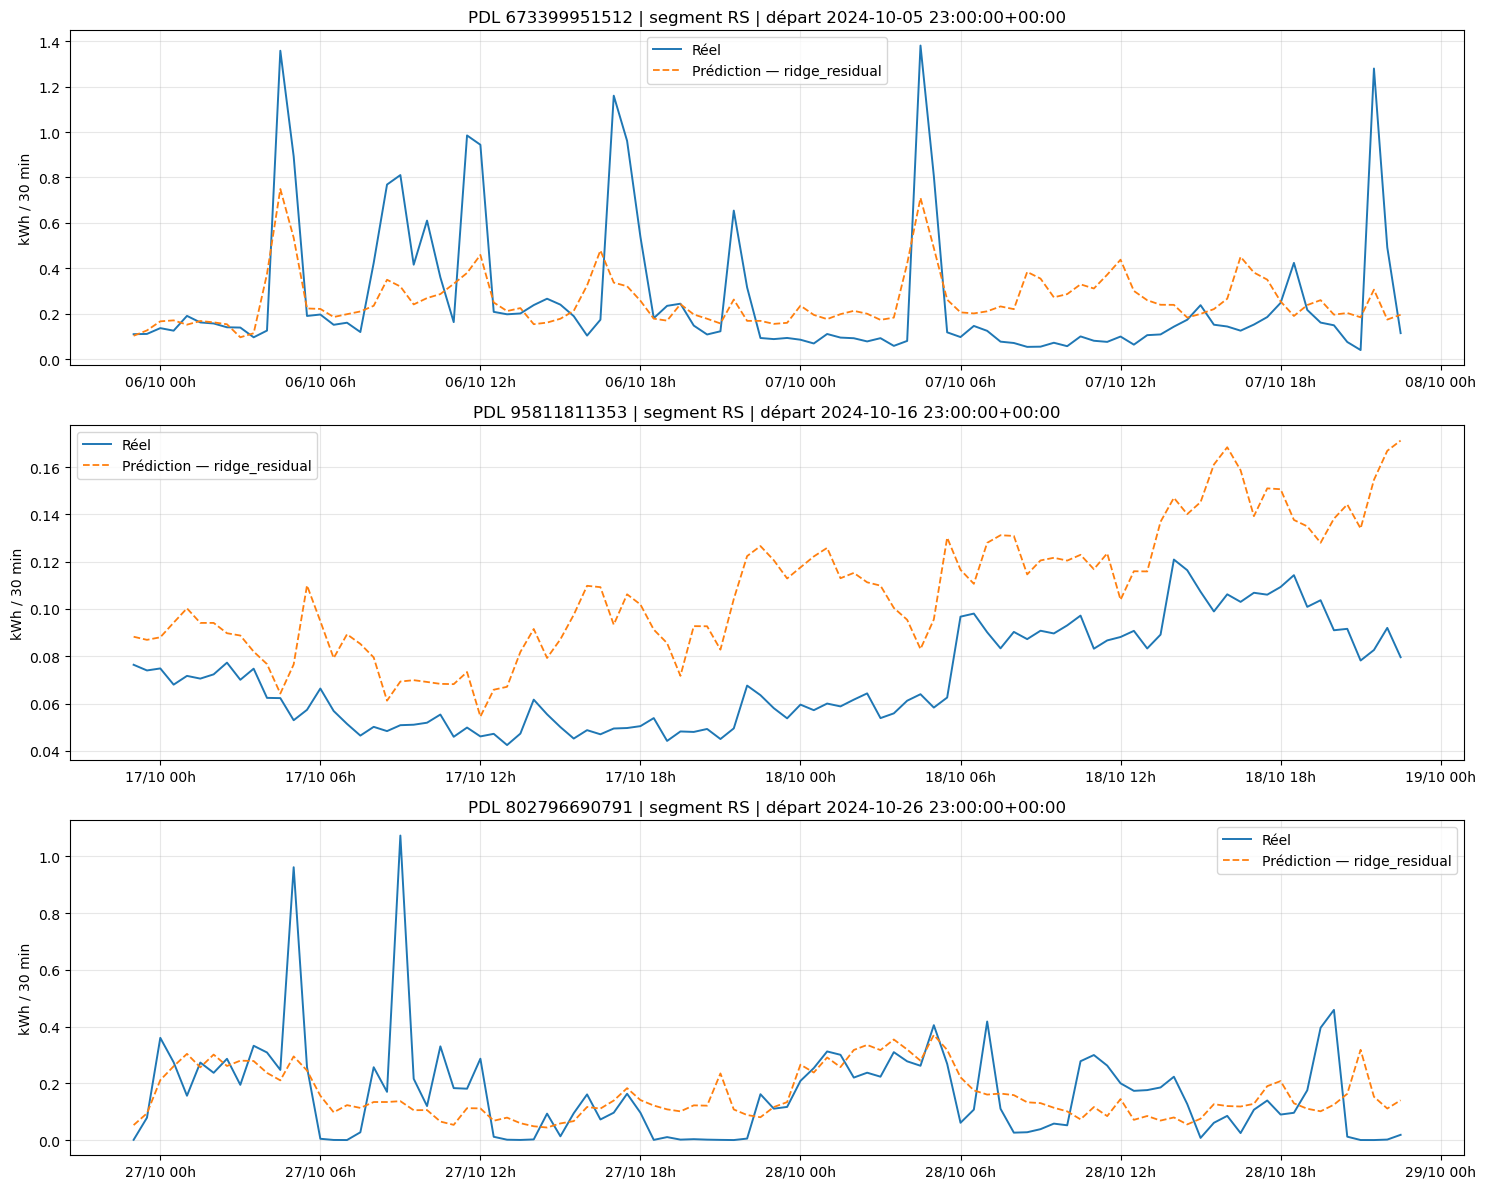

In [18]:
def get_prediction_array(model_name):
    if model_name == "baseline_recent":
        return B_recent
    if model_name == "baseline_weekly":
        return B_weekly
    if model_name == "ridge_residual":
        full_pred = np.empty_like(Y)
        full_pred[:] = np.nan
        # On calcule seulement pour val + test afin d'éviter de stocker inutilement pour tout le train.
        for idx_part in [idx_val, idx_test]:
            pred_res = ridge_model.predict(X_tab[idx_part]).astype(np.float32)
            full_pred[idx_part] = np.clip(B_base[idx_part] + pred_res, 0, None)
        return full_pred
    if model_name == "cnn_residual" and pred_cnn_test is not None:
        full_pred = np.empty_like(Y)
        full_pred[:] = np.nan
        full_pred[idx_test] = pred_cnn_test
        return full_pred
    return B_weekly

# On visualise le meilleur modèle ALL selon validation, si disponible.
model_to_plot = best_by_val.get("ALL", "baseline_weekly")
Y_pred_plot = get_prediction_array(model_to_plot)

rng = np.random.default_rng(RANDOM_STATE)
plot_indices = rng.choice(idx_test, size=min(3, len(idx_test)), replace=False)

fig, axes = plt.subplots(len(plot_indices), 1, figsize=(15, 4 * len(plot_indices)))
if len(plot_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, plot_indices):
    start_time = forecast_starts.iloc[idx]
    dates = pd.date_range(start=start_time, periods=HORIZON, freq="30min")
    ax.plot(dates, Y[idx], label="Réel", linewidth=1.4)
    ax.plot(dates, Y_pred_plot[idx], label=f"Prédiction — {model_to_plot}", linewidth=1.3, linestyle="--")
    ax.set_title(f"PDL {windows.iloc[idx]['pdl_id']} | segment {windows.iloc[idx]['segment']} | départ {start_time}")
    ax.set_ylabel("kWh / 30 min")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## 10. Fonction de prédiction pour un client donné

La fonction ci-dessous prend un `pdl_id`, récupère ses 14 derniers jours observés, et renvoie la prédiction des 2 jours suivants avec le modèle choisi.

In [19]:
def predict_next_2_days_for_client(pdl_id, model_name=None):
    if model_name is None:
        model_name = best_by_val.get("ALL", "baseline_weekly")

    g = raw[raw["pdl_id"] == pdl_id].sort_values("horodate")
    if len(g) < INPUT_LEN:
        raise ValueError(f"Historique insuffisant pour le client {pdl_id}.")

    segment = g["segment"].iloc[-1]
    values = g["kwh"].to_numpy(dtype=np.float32)
    times = g["horodate"].to_numpy()

    past_seq = values[-INPUT_LEN:]
    anchor_time = pd.Timestamp(times[-1])
    forecast_start = anchor_time + pd.Timedelta(minutes=30)
    future_dates = pd.date_range(start=forecast_start, periods=HORIZON, freq="30min")

    extra = build_extra_features(past_seq, anchor_time, segment).reshape(1, -1)
    x_seq_one = past_seq.reshape(1, -1)
    x_tab_one = np.hstack([x_seq_one, extra]).astype(np.float32)

    b_recent = past_seq[-HORIZON:].reshape(1, -1)
    b_weekly = past_seq[INPUT_LEN - 336:INPUT_LEN - 336 + HORIZON].reshape(1, -1)
    b_base_one = b_recent if BASELINE_MODEL == "baseline_recent" else b_weekly

    if model_name == "baseline_recent":
        pred = b_recent[0]
    elif model_name == "baseline_weekly":
        pred = b_weekly[0]
    elif model_name == "ridge_residual":
        pred_res = ridge_model.predict(x_tab_one).astype(np.float32)
        pred = np.clip(b_base_one + pred_res, 0, None)[0]
    elif model_name == "cnn_residual" and cnn_model is not None:
        x_seq_scaled = (x_seq_one / seq_scale).astype(np.float32)
        x_extra_scaled = ((extra - extra_mean) / extra_std).astype(np.float32)
        cnn_model.eval()
        with torch.no_grad():
            xb_seq = torch.from_numpy(x_seq_scaled).to(DEVICE)
            xb_extra = torch.from_numpy(x_extra_scaled).to(DEVICE)
            pred_res = cnn_model(xb_seq, xb_extra).cpu().numpy() * seq_scale
        pred = np.clip(b_base_one + pred_res, 0, None)[0]
    else:
        raise ValueError(f"Modèle inconnu ou non disponible : {model_name}")

    out = pd.DataFrame({
        "horodate": future_dates,
        "prediction_kwh": pred,
        "pdl_id": pdl_id,
        "segment": segment,
        "modele": model_name,
    })
    return out

# Exemple d'utilisation avec le premier client disponible
example_pdl = raw["pdl_id"].iloc[0]
forecast_example = predict_next_2_days_for_client(example_pdl)
print(f"Exemple de prédiction pour le client {example_pdl}")
display(forecast_example.head())



Exemple de prédiction pour le client 1704875583


,horodate,prediction_kwh,pdl_id,segment,modele
0,2024-10-29 23:00:00+00:00,0.242809,1704875583,RS,ridge_residual
1,2024-10-29 23:30:00+00:00,0.210872,1704875583,RS,ridge_residual
2,2024-10-30 00:00:00+00:00,0.179668,1704875583,RS,ridge_residual
3,2024-10-30 00:30:00+00:00,0.218599,1704875583,RS,ridge_residual
4,2024-10-30 01:00:00+00:00,0.228492,1704875583,RS,ridge_residual
